# Проверка качества данных: Supermarket Sales
Датасет: https://www.kaggle.com/datasets/chadwambles/supermarket-sales

Профилирование pandas: count / distinct, null, длины строк, описательные статистики, перцентили, PSI, stddev, корреляции, topX, гистограммы.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 50)

## 1. Загрузка данных
Файл `sales.csv` должен лежать рядом с ноутбуком.

In [2]:
df = pd.read_csv('sales.csv')
print(df.shape)
df.head()

(1000, 12)


,sale_id,branch,city,customer_type,gender,product_name,product_category,unit_price,quantity,tax,total_price,reward_points
0,1,A,New York,Member,Male,Shampoo,Personal Care,5.50,3,1.16,17.66,1
1,2,B,Los Angeles,Normal,Female,Notebook,Stationery,2.75,10,1.93,29.43,0
2,3,A,New York,Member,Female,Apple,Fruits,1.20,15,1.26,19.26,1
3,4,A,Chicago,Normal,Male,Detergent,Household,7.80,5,2.73,41.73,0
4,5,B,Los Angeles,Member,Female,Orange Juice,Beverages,3.50,7,1.72,26.22,2


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sale_id           1000 non-null   int64  
 1   branch            1000 non-null   str    
 2   city              1000 non-null   str    
 3   customer_type     1000 non-null   str    
 4   gender            1000 non-null   str    
 5   product_name      1000 non-null   str    
 6   product_category  1000 non-null   str    
 7   unit_price        1000 non-null   float64
 8   quantity          1000 non-null   int64  
 9   tax               1000 non-null   float64
 10  total_price       1000 non-null   float64
 11  reward_points     1000 non-null   int64  
dtypes: float64(3), int64(3), str(6)
memory usage: 131.2 KB


In [4]:
# Приведение типов
num_cols = df.select_dtypes('number').columns.tolist()
cat_cols = df.select_dtypes(exclude='number').columns.tolist()
print('numeric:', num_cols); print('categorical:', cat_cols)

numeric: ['sale_id', 'unit_price', 'quantity', 'tax', 'total_price', 'reward_points']
categorical: ['branch', 'city', 'customer_type', 'gender', 'product_name', 'product_category']


## 2. Count / Count distinct / Null / Not null

In [5]:
n = len(df)
cnt = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'count (not null)': df.notna().sum(),
    'count null': df.isna().sum(),
    'null %': (df.isna().mean() * 100).round(2),
    'count distinct': df.nunique(),
    'distinct %': (df.nunique() / n * 100).round(2),
})
print('Всего строк:', n, '| полных дубликатов:', df.duplicated().sum())
cnt

Всего строк: 1000 | полных дубликатов: 0


,dtype,count (not null),count null,null %,count distinct,distinct %
sale_id,int64,1000,0,0.0,1000,100.0
branch,str,1000,0,0.0,2,0.2
city,str,1000,0,0.0,3,0.3
customer_type,str,1000,0,0.0,2,0.2
gender,str,1000,0,0.0,2,0.2
product_name,str,1000,0,0.0,5,0.5
product_category,str,1000,0,0.0,5,0.5
unit_price,float64,1000,0,0.0,787,78.7
quantity,int64,1000,0,0.0,20,2.0
tax,float64,1000,0,0.0,755,75.5


## 3. Длина значений (Max / Min / Avg)
Длина строкового представления значения для каждой колонки.

In [6]:
def len_stats(s):
    l = s.dropna().astype(str).str.len()
    return pd.Series({'min len': l.min(), 'max len': l.max(), 'avg len': round(l.mean(), 2)})
df.apply(len_stats).T

,min len,max len,avg len
sale_id,1.0,4.0,2.89
branch,1.0,1.0,1.00
city,7.0,11.0,8.65
customer_type,6.0,6.0,6.00
gender,4.0,6.0,4.94
product_name,5.0,12.0,8.24
product_category,6.0,13.0,9.40
unit_price,3.0,5.0,4.41
quantity,1.0,2.0,1.54
tax,3.0,5.0,4.21


## 4. Max / Min / Avg / Median / Mean / Stddev / Percentile (числовые)

In [7]:
q = [.01, .05, .25, .5, .75, .95, .99]
stats = df[num_cols].agg(['count', 'min', 'max', 'mean', 'median', 'std']).T
pct = df[num_cols].quantile(q).T
pct.columns = [f'p{int(x * 100)}' for x in q]
stats = stats.join(pct)

def n_outliers(s):
    q1, q3 = s.quantile(.25), s.quantile(.75)
    i = q3 - q1
    return int(((s < q1 - 1.5 * i) | (s > q3 + 1.5 * i)).sum())

stats['iqr outliers'] = [n_outliers(df[c]) for c in num_cols]
stats

,count,min,max,mean,median,std,p1,p5,p25,p50,p75,p95,p99,iqr outliers
sale_id,1000.0,1.00,1000.00,500.50000,500.500,288.819436,10.9900,50.9500,250.7500,500.500,750.2500,950.0500,990.0100,0
unit_price,1000.0,1.02,20.98,10.83611,10.615,5.775924,1.1297,1.9195,5.8675,10.615,15.8825,19.9615,20.8101,0
quantity,1000.0,1.00,20.00,10.33700,10.000,6.029908,1.0000,1.0000,5.0000,10.000,16.0000,20.0000,20.0000,0
tax,1000.0,0.08,28.39,7.75801,5.870,6.538066,0.2100,0.6800,2.5100,5.870,11.5225,20.9355,26.3105,15
total_price,1000.0,1.21,433.99,118.58390,89.705,99.936441,3.2295,10.4380,38.3800,89.705,176.0725,320.0725,402.1181,15
reward_points,1000.0,0.00,43.00,6.05700,0.000,9.350464,0.0000,0.0000,0.0000,0.000,10.0000,28.0000,37.0000,64


## 5. Corr Matrix

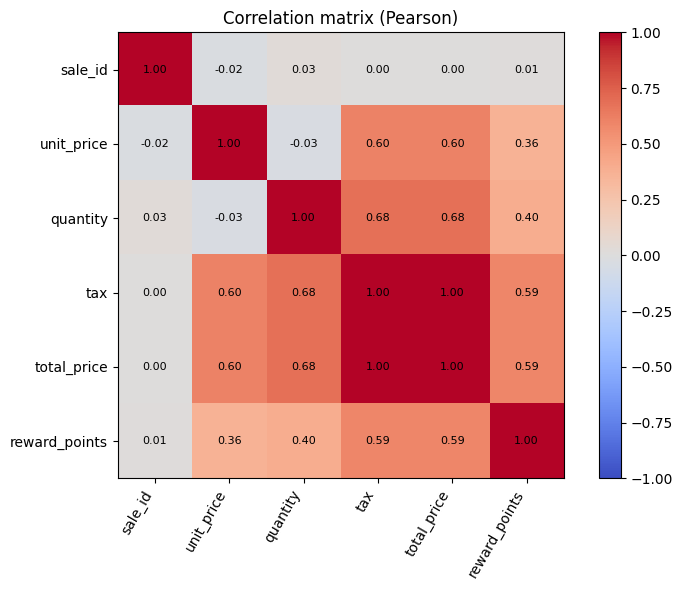

,sale_id,unit_price,quantity,tax,total_price,reward_points
sale_id,1.000,-0.024,0.027,0.000,0.000,0.009
unit_price,-0.024,1.000,-0.034,0.602,0.602,0.362
quantity,0.027,-0.034,1.000,0.684,0.684,0.398
tax,0.000,0.602,0.684,1.000,1.000,0.591
total_price,0.000,0.602,0.684,1.000,1.000,0.591
reward_points,0.009,0.362,0.398,0.591,0.591,1.000


In [8]:
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols)), num_cols, rotation=60, ha='right')
ax.set_yticks(range(len(num_cols)), num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im); plt.title('Correlation matrix (Pearson)'); plt.tight_layout(); plt.show()
corr.round(3)

In [9]:
# Пары с |corr| > 0.95 (возможная избыточность / производные признаки)
pairs = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack()
pairs[pairs.abs() > 0.95].sort_values(key=abs, ascending=False)

tax  total_price    1.0
dtype: float64

## 6. TopX значений

In [10]:
X = 5
for c in cat_cols:
    vc = df[c].value_counts(dropna=False).head(X)
    print(f'--- {c} (distinct={df[c].nunique()}) ---')
    print(pd.DataFrame({'count': vc, 'share %': (vc / n * 100).round(2)}), '\n')

--- branch (distinct=2) ---
        count  share %
branch                
A         674     67.4
B         326     32.6 

--- city (distinct=3) ---
             count  share %
city                       
New York       344     34.4
Chicago        330     33.0
Los Angeles    326     32.6 

--- customer_type (distinct=2) ---
               count  share %
customer_type                
Member           516     51.6
Normal           484     48.4 

--- gender (distinct=2) ---
        count  share %
gender                
Male      528     52.8
Female    472     47.2 

--- product_name (distinct=5) ---
              count  share %
product_name                
Shampoo         224     22.4
Orange Juice    208     20.8
Notebook        194     19.4
Detergent       189     18.9
Apple           185     18.5 

--- product_category (distinct=5) ---
                  count  share %
product_category                
Fruits              209     20.9
Personal Care       208     20.8
Stationery          19

In [11]:
for c in num_cols:
    vc = df[c].value_counts(dropna=False).head(X)
    print(f'--- {c} ---')
    print(pd.DataFrame({'count': vc, 'share %': (vc / n * 100).round(2)}), '\n')

--- sale_id ---
         count  share %
sale_id                
1            1      0.1
2            1      0.1
3            1      0.1
4            1      0.1
5            1      0.1 

--- unit_price ---
            count  share %
unit_price                
17.25           5      0.5
11.33           4      0.4
1.09            4      0.4
10.77           4      0.4
8.81            3      0.3 

--- quantity ---
          count  share %
quantity                
2            73      7.3
18           58      5.8
1            57      5.7
19           57      5.7
3            53      5.3 

--- tax ---
      count  share %
tax                 
4.59      5      0.5
1.43      5      0.5
2.72      5      0.5
2.90      5      0.5
1.44      4      0.4 

--- total_price ---
             count  share %
total_price                
60.67            3      0.3
212.82           2      0.2
218.22           2      0.2
70.11            2      0.2
163.84           2      0.2 

--- reward_points ---
         

## 7. Гистограммы

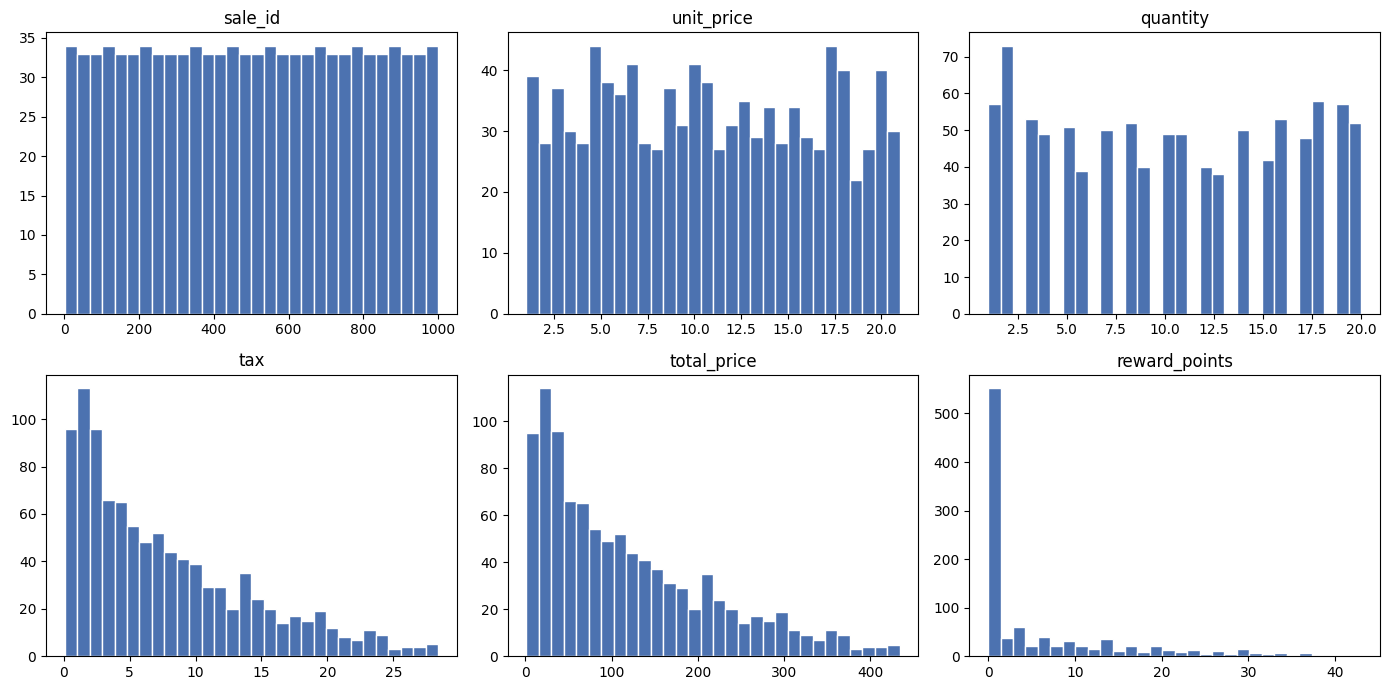

In [12]:
k = len(num_cols); ncols = 3; rows = int(np.ceil(k / ncols))
fig, axes = plt.subplots(rows, ncols, figsize=(14, 3.5 * rows)); axes = np.array(axes).ravel()
for ax, c in zip(axes, num_cols):
    ax.hist(df[c].dropna(), bins=30, color='#4C72B0', edgecolor='white'); ax.set_title(c)
for ax in axes[k:]:
    ax.axis('off')
plt.tight_layout(); plt.show()

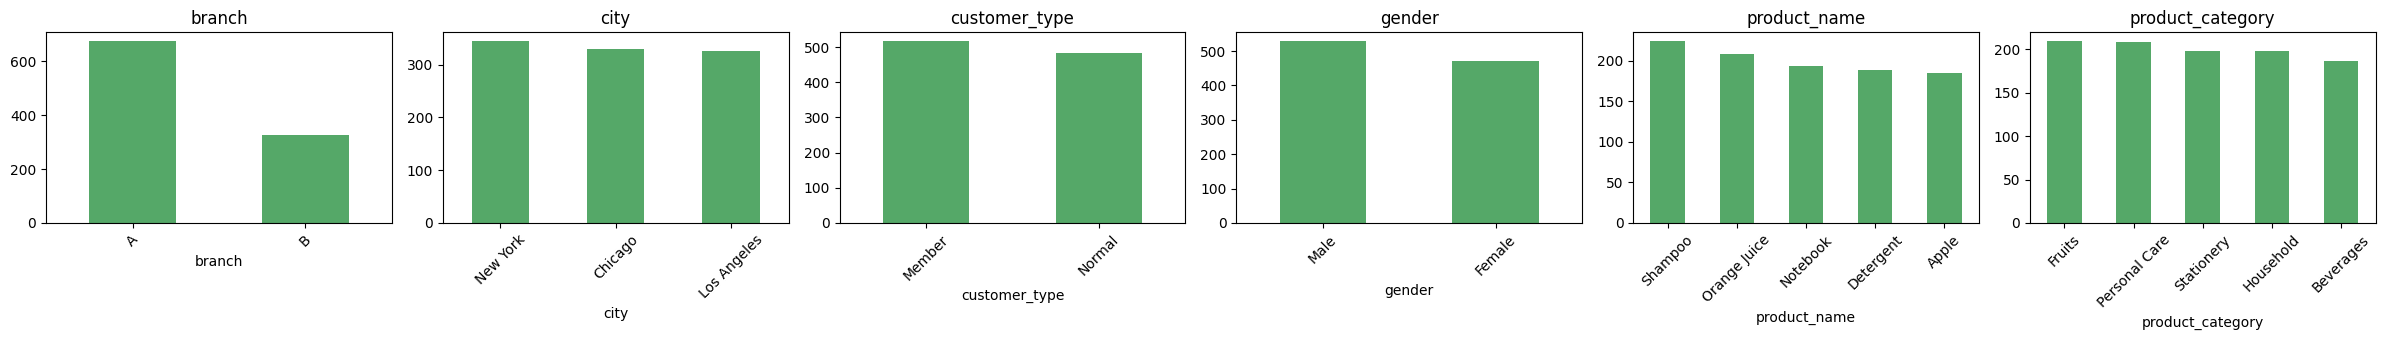

In [13]:
# Частоты категориальных признаков с небольшим числом значений
small = [c for c in cat_cols if df[c].nunique() <= 10]
fig, axes = plt.subplots(1, len(small), figsize=(4 * len(small), 3.5))
axes = np.atleast_1d(axes)
for ax, c in zip(axes, small):
    df[c].value_counts().plot.bar(ax=ax, color='#55A868'); ax.set_title(c); ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

## 8. PSI (Population Stability Index)
PSI = Σ (a_i − e_i) · ln(a_i / e_i), где e — доля в базовой выборке, a — в сравниваемой.
Интерпретация: < 0.1 — стабильно, 0.1–0.25 — умеренный сдвиг, > 0.25 — значимый сдвиг.

Выборки: **baseline** — первая половина строк, **current** — вторая половина (даты в данных нет).

In [14]:
def psi_num(e, a, bins=10):
    e, a = e.dropna(), a.dropna()
    edges = np.unique(np.quantile(e, np.linspace(0, 1, bins + 1)))
    if len(edges) < 3:
        return np.nan
    edges[0], edges[-1] = -np.inf, np.inf
    pe = np.histogram(e, edges)[0] / len(e); pa = np.histogram(a, edges)[0] / len(a)
    pe, pa = np.clip(pe, 1e-4, None), np.clip(pa, 1e-4, None)
    return float(np.sum((pa - pe) * np.log(pa / pe)))

def psi_cat(e, a):
    cats = sorted(set(e.dropna()) | set(a.dropna()))
    pe = e.value_counts(normalize=True).reindex(cats).fillna(0).clip(1e-4)
    pa = a.value_counts(normalize=True).reindex(cats).fillna(0).clip(1e-4)
    return float(np.sum((pa - pe) * np.log(pa / pe)))

base, curr = df.iloc[:n // 2], df.iloc[n // 2:]
res = {c: psi_num(base[c], curr[c]) for c in num_cols if df[c].nunique() < n}
res.update({c: psi_cat(base[c], curr[c]) for c in cat_cols if df[c].nunique() <= 50})
psi = pd.Series(res, name='PSI').to_frame()
psi['status'] = pd.cut(psi['PSI'], [-np.inf, .1, .25, np.inf], labels=['stable', 'moderate shift', 'significant shift'])
print('baseline:', len(base), 'current:', len(curr))
psi.sort_values('PSI', ascending=False)

baseline: 500 current: 500


,PSI,status
quantity,0.052562,stable
city,0.033617,stable
branch,0.026378,stable
product_category,0.024955,stable
unit_price,0.018180,stable
tax,0.017042,stable
total_price,0.015422,stable
product_name,0.006734,stable
reward_points,0.003595,stable
gender,0.000064,stable


## 9. Дополнительные проверки качества

In [15]:
issues = []
issues.append(('Пропуски', int(df.isna().sum().sum())))
issues.append(('Полные дубликаты', int(df.duplicated().sum())))
for c in [c for c in df.columns if c.lower().endswith('id')]:
    issues.append((f'Дубликаты {c}', int(df[c].duplicated().sum())))
for c in num_cols:
    neg = int((df[c] < 0).sum())
    if neg:
        issues.append((f'Отрицательные {c}', neg))
if {'unit_price', 'quantity', 'tax', 'total_price'} <= set(df.columns):
    issues.append(('total_price != unit_price*quantity+tax',
                   int((~np.isclose(df['total_price'], df['unit_price'] * df['quantity'] + df['tax'], atol=0.011)).sum())))
for c in cat_cols:
    s = df[c].dropna()
    k = int((s != s.str.strip()).sum())
    if k:
        issues.append((f'Лишние пробелы {c}', k))
pd.DataFrame(issues, columns=['check', 'violations'])

,check,violations
0,Пропуски,0
1,Полные дубликаты,0
2,Дубликаты sale_id,0
3,total_price != unit_price*quantity+tax,0


## 10. Выводы
В датасете 1000 продаж и 12 колонок. Пропусков нет, дубликатов тоже нет, `sale_id` уникален, типы данных определились правильно. Так что с точки зрения базовой чистоты к данным претензий нет. Единственное, чего не хватает, это даты продажи, поэтому посмотреть динамику по времени не получилось.

Категориальные признаки распределены довольно ровно: три города по трети каждый, пять товаров и пять категорий примерно по 20%, мужчин и женщин почти поровну. Заметный перекос только по филиалам: на A приходится 67%, на B 33%.

По числовым колонкам: цена товара от 1 до 21, количество от 1 до 20, сумма чека в среднем около 119 при медиане около 90. Среднее больше медианы, а std почти равен среднему, так что чеки скошены вправо. Это подтверждают и гистограммы, и 15 выбросов по IQR у `tax` и `total_price`. Это просто дорогие покупки (большая цена на большое количество), на ошибки не похоже.

У `reward_points` в половине строк стоит 0. Оказалось, что баллы есть только у клиентов типа Member, а у Normal всегда 0, то есть это логика программы лояльности, а не пропуски.

В матрице корреляций `tax` и `total_price` связаны на 1.0: налог везде примерно 7% от стоимости, а итог равен цена * количество + налог (эту формулу я проверил, нарушений нет). Поэтому для анализа достаточно одной из этих двух колонок. Цена и количество между собой не связаны.

PSI между первой и второй половиной выборки у всех признаков меньше 0.1, значит распределения стабильны. Для `sale_id` PSI не считал, это просто номер по порядку.

В целом данные чистые и пригодны для дальнейшего анализа.